
**-----PROJEKT--GRUPP6-----** <br>
Pär Hedström<br>
Fredrik Domert Eriksson<br>
Rickard Andersson<br>

**Data Collection Spider**<br>
Jag har gjort ett försök till att bygga en Spider som utför Web Scraping. Den simulerar en mänsklig användare för att hämta strukturerad data från en databas. Eller i det här fallet en webbsida. Jag har byggt den ganska generellt just med filter-valen, det kan vi ju ändra lite som vi vill sen när vi är överens. Men den fungerar bra. Den laddar ner en csv-fil i en mapp (data_folder) som skapas i den mapp där jupyter-filen ligger. När man kör koden så kommer hemsidan upp och sen tar det kanske 10 sek innan den skriver i sökfältet. /RA

In [3]:
# Använt kod från https://www.geeksforgeeks.org/web-scraping/scrape-linkedin-using-selenium-and-beautiful-soup-in-python/

# Installerar selenium för att kunna hantera knappar och menyer
%pip install selenium

Note: you may need to restart the kernel to use updated packages.


In [4]:
# Importerar dom bibliotek vi behöver

from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.chrome.options import Options
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
from selenium.webdriver.common.keys import Keys
from selenium.webdriver.support.ui import Select
import time
import os

# --- KONFIGURATION & SÖKVÄGAR ---
SEARCH_TERM = "Avsiktligt självdestruktiv handling"
DATA_DIR = os.path.join(os.getcwd(), "data_folder")

# Skapar en mapp om den inte redan finns
if not os.path.exists(DATA_DIR):
    os.makedirs(DATA_DIR)

chrome_options = Options()
chrome_options.add_experimental_option("prefs", {
    "download.default_directory": DATA_DIR,
    "download.prompt_for_download": False,
    "download.directory_upgrade": True,
    "safebrowsing.enabled": True
})

driver = webdriver.Chrome(options=chrome_options)
wait = WebDriverWait(driver, 20)

# Här startas sidan (socialstyrelsen) där man kan välja filter och använda sökfältet 
try:
    print(f"Startar sökning. Filer kommer sparas i: {DATA_DIR}")
    driver.get("https://sdb.socialstyrelsen.se/if_dor/val.aspx")

    print("Väljer månadsuppgifter...")
    # Det första vi vill göra är att välja månadsuppgifter då det ändrar filtreringen
    try:
        # Vi letar efter select-elementet inuti diven
        select_ar_manad = wait.until(EC.presence_of_element_located((By.CSS_SELECTOR, "div[id*='armanad_ind'] select"))) # Div-element för År/månadsuppgifter
        s_typer = Select(select_ar_manad)
        s_typer.select_by_visible_text("Månadsuppgifter")
        
        # Trigga sidans eget skript för att rita om gränssnittet till månadsvisning
        driver.execute_script("arguments[0].onchange();", select_ar_manad)
    except Exception as e:
        # Om select-logiken inte fungerar
        print("Kör reservmetod för månadsuppgifter...")
        driver.execute_script("document.querySelector(\"div[id*='armanad_ind'] select\").value = 'm';")
    time.sleep(2.5)

    # Om det ligger gamla val eller text i sökfält så rensas det
    print("Nollställer tidigare val...")
    try:
        rensa = wait.until(EC.element_to_be_clickable((By.ID, "ph1_val_dia_id_btnRensaValda"))) # html-element för rensning av val
        driver.execute_script("arguments[0].click();", rensa)
    except:
        pass

    # Använder sökfältet
    print(f"Söker efter: '{SEARCH_TERM}'...")
    sok_falt = wait.until(EC.element_to_be_clickable((By.ID, "Sokord"))) # html-element för sökfält
    sok_falt.clear()
    sok_falt.send_keys(SEARCH_TERM)
    sok_falt.send_keys(Keys.ENTER)

    # Bockar i rutor för sökresultat
    # Har lagt ut några print då det krånglade en del så jag kunde se vart det tog stopp
    print("Markerar diagnosrutor...")
    wait.until(EC.presence_of_element_located((By.CSS_SELECTOR, "#sokListaArea input[type='checkbox']"))) # html-element för checkbox sök-resultat
    checkboxar = driver.find_elements(By.CSS_SELECTOR, "#sokListaArea input[type='checkbox']")
    for cb in checkboxar:
        if not cb.is_selected():
            driver.execute_script("arguments[0].click();", cb)
    
    # Filter för Ålder, Kön och månad där vi bockar i Välj alla
    print("Väljer filter...")
    time.sleep(1)
    knappar_att_klicka = [
        "ph1_val_kon_id_hlAdd",    # Välj alla för Kön
        "ph1_val_ar_id_hlAdd",     # Välj alla för År
        "ph1_val_manad_id_hlAdd"   # Välj alla för Månad
    ]
    
    for knap_id in knappar_att_klicka:
        try:
            knapp = driver.find_element(By.ID, knap_id)
            driver.execute_script("arguments[0].click();", knapp)
            time.sleep(0.1)
        except Exception as e:
            print(f"Kunde inte klicka på filter {knap_id}: {e}")

    # Letar upp knappen för Visa resultat
    # Generera tabell och hämta CSV
    print("Genererar tabell...")
    try:
        # Kör javascript-funktionen direkt
        driver.execute_script("submitResultat();")
    except:
        # Backup om JS-anropet krånglar
        visa_lank = wait.until(EC.element_to_be_clickable((By.ID, "ph1_val_data_id_lnkVisaResultat"))) # html-element
        driver.execute_script("arguments[0].click();", visa_lank)

    # Nu har vi kommit till resultat-sidan av vår sökning.
    # Högst upp till höger letar vi på csv-länken som laddar ner filen till vår mapp.
    print("Hämtar CSV-fil...")
    csv_knapp = wait.until(EC.element_to_be_clickable((By.CSS_SELECTOR, "a[id$='lbCSV']")))
    driver.execute_script("arguments[0].scrollIntoView({block: 'center'});", csv_knapp)
    time.sleep(0.5)
    csv_knapp.click()
    
    print(f"KLART! Din data ligger nu i din mapp.")
    time.sleep(2) # Tid för Chrome då det gick lite för fort tidigare

except Exception as e:
    print(f"Ett fel uppstod: {e}")

# Stänger ner sidan när allt är klart
finally:
    # Vi kollar om driver existerar innan vi försöker stänga den
    if 'driver' in locals() or 'driver' in globals():
        try:
            driver.close() # Stänger fliken
            driver.quit()  # Stänger hela programmet
            print("Webbläsaren stängdes korrekt.")
        except:
            pass # Om den redan var stängd gör vi ingenting

Startar sökning. Filer kommer sparas i: c:\Users\Lenovo\Desktop\Högskolan Dalarna\Projekt - ML -Grupp 6\projekt-grupp6\data_folder
Väljer månadsuppgifter...
Kör reservmetod för månadsuppgifter...
Nollställer tidigare val...
Söker efter: 'Avsiktligt självdestruktiv handling'...
Markerar diagnosrutor...
Väljer filter...
Genererar tabell...
Hämtar CSV-fil...
KLART! Din data ligger nu i din mapp.
Webbläsaren stängdes korrekt.


**Data-Analys**

**Visualisering**

In [6]:
import pandas as pd
import numpy as np

# 1. Ladda in datan
# skiprows=1 hoppar över den allra översta raden med metadata, 
# så att raden med "Kön;Januari 1997..." blir våra faktiska kolumnnamn.
file_path = 'data_folder/Statistikdatabasen_2026-05-19 13_05_32.csv'
df = pd.read_csv(file_path, sep=';', skiprows=1)

# 2. Rensa bort texten i botten
# Vi behåller bara de tre raderna som faktiskt innehåller könen.
df = df[df['Kön'].isin(['Män', 'Kvinnor', 'Båda könen'])]

# 3. Magin: Omforma datan från Bred till Lång (Melt)
# Detta tar alla hundratals månadskolumner och lägger dem i en enda kolumn som heter 'Tid'.
df_long = pd.melt(df, id_vars=['Kön'], var_name='Tid', value_name='Antal')

# 4. Städa bort saknad data
# Socialstyrelsen använder ibland '­­' för månader som inte har data än (ex slutet av 2026)
# Vi gör om dessa till "Not a Number" (NaN) och droppar dem, samt ser till att antalet är siffror.
df_long['Antal'] = pd.to_numeric(df_long['Antal'].replace('­­', np.nan), errors='coerce')
df_long = df_long.dropna(subset=['Antal'])

# 5. Den nya uppdaterade ordlistan för hela månadsnamn
month_map = {
    'Januari': '01', 'Februari': '02', 'Mars': '03', 'April': '04',
    'Maj': '05', 'Juni': '06', 'Juli': '07', 'Augusti': '08',
    'September': '09', 'Oktober': '10', 'November': '11', 'December': '12'
}

# 6. Översätt månaderna (t.ex. görs "Januari 1997" om till "01 1997")
for swe_month, num_month in month_map.items():
    df_long['Tid'] = df_long['Tid'].str.replace(swe_month, num_month)

# ... (allt innan steg 7 är exakt som förut)

# 7. Konvertera texten till Pandas-datum (skapar först 1997-01-01 internt)
df_long['Datum'] = pd.to_datetime(df_long['Tid'], format='%m %Y')

# 8. Sätt datumet som Index
df_long.set_index('Datum', inplace=True)

# NYTT TILLÄGG: Gör om indexet från "Exakt dag" till "Månadsperiod" (t.ex. 1997-01)
df_long.index = df_long.index.to_period('M')

# Sortera kronologiskt
df_long = df_long.sort_index()

# Titta på resultatet
display(df_long.head())

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_29740\2538553814.py:21: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_long['Antal'] = pd.to_numeric(df_long['Antal'].replace('­­', np.nan), errors='coerce')


,Kön,Tid,Antal
Datum,,,
1997-01,Män,01 1997,82.0
1997-01,Kvinnor,01 1997,22.0
1997-01,Båda könen,01 1997,104.0
1997-02,Män,02 1997,70.0
1997-02,Kvinnor,02 1997,29.0


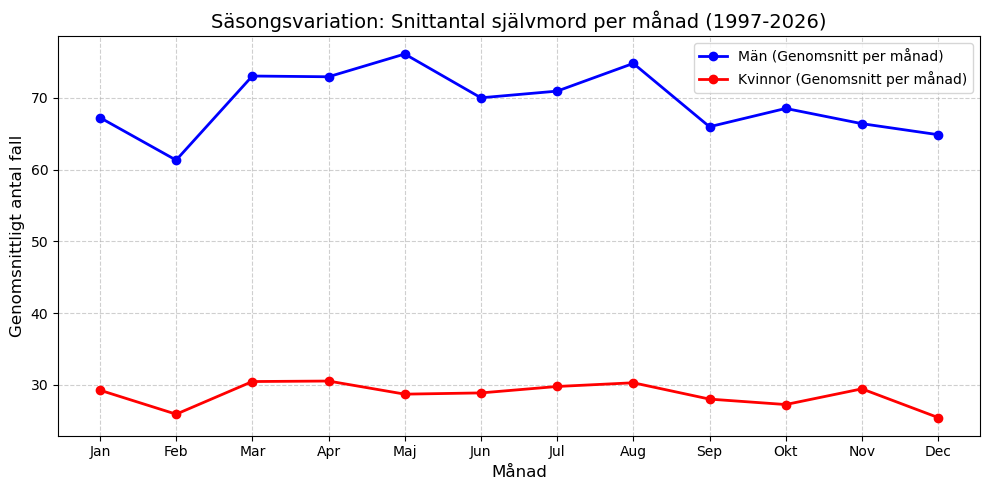

In [7]:
import matplotlib.pyplot as plt

# 1. Skapa en ny kolumn som bara innehåller månadens siffra (1-12)
df_long['Månad_Nr'] = df_long.index.month

# 2. Filtrera för könen
df_men = df_long[df_long['Kön'] == 'Män']
df_women = df_long[df_long['Kön'] == 'Kvinnor']

# 3. Gruppera per månad (1-12) och räkna ut genomsnittet över alla år
monthly_avg_men = df_men.groupby('Månad_Nr')['Antal'].mean()
monthly_avg_women = df_women.groupby('Månad_Nr')['Antal'].mean()

# 4. Bygg upp grafen
plt.figure(figsize=(10, 5))

# Plotta linjerna med små prickar (marker='o') för varje månad
plt.plot(monthly_avg_men.index, monthly_avg_men.values, marker='o', color='blue', linewidth=2, label='Män (Genomsnitt per månad)')
plt.plot(monthly_avg_women.index, monthly_avg_women.values, marker='o', color='red', linewidth=2, label='Kvinnor (Genomsnitt per månad)')

# Formatering av grafen
plt.title('Säsongsvariation: Snittantal självmord per månad (1997-2026)', fontsize=14)
plt.xlabel('Månad', fontsize=12)
plt.ylabel('Genomsnittligt antal fall', fontsize=12)

# Byt ut siffrorna på X-axeln mot riktiga månadsnamn
plt.xticks(range(1, 13), ['Jan', 'Feb', 'Mar', 'Apr', 'Maj', 'Jun', 'Jul', 'Aug', 'Sep', 'Okt', 'Nov', 'Dec'])

plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()

# Visa grafen
plt.show()

In [3]:
%pip install prophet scikit-learn

   ---------------------------------------- 0.0/12.1 MB ? eta -:--:--
   ------------------ --------------------- 5.5/12.1 MB 28.6 MB/s eta 0:00:01
   -------------------------------------- - 11.5/12.1 MB 28.7 MB/s eta 0:00:01
   ---------------------------------------- 12.1/12.1 MB 26.0 MB/s eta 0:00:00
   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ---------------------------------------- 1.5/1.5 MB 24.3 MB/s eta 0:00:00

   -------- ------------------------------- 1/5 [importlib_resources]
   ---------------- ----------------------- 2/5 [holidays]
   ---------------- ----------------------- 2/5 [holidays]
   ---------------- ----------------------- 2/5 [holidays]
   ---------------- ----------------------- 2/5 [holidays]
   ---------------- ----------------------- 2/5 [holidays]
   ---------------- ----------------------- 2/5 [holidays]
   ---------------- ----------------------- 2/5 [holidays]
   ---------------- ----------------------- 2/5 [holidays]
   --

--- STARTAR MASKININLÄRNING (PROPHET) ---
Tränar modellen på 324 månader...


11:09:06 - cmdstanpy - INFO - Chain [1] start processing
11:09:07 - cmdstanpy - INFO - Chain [1] done processing


✅ STATISTISK VERIFIERING: Modellen gissar i snitt fel på 6.3 fall per månad för 2024.


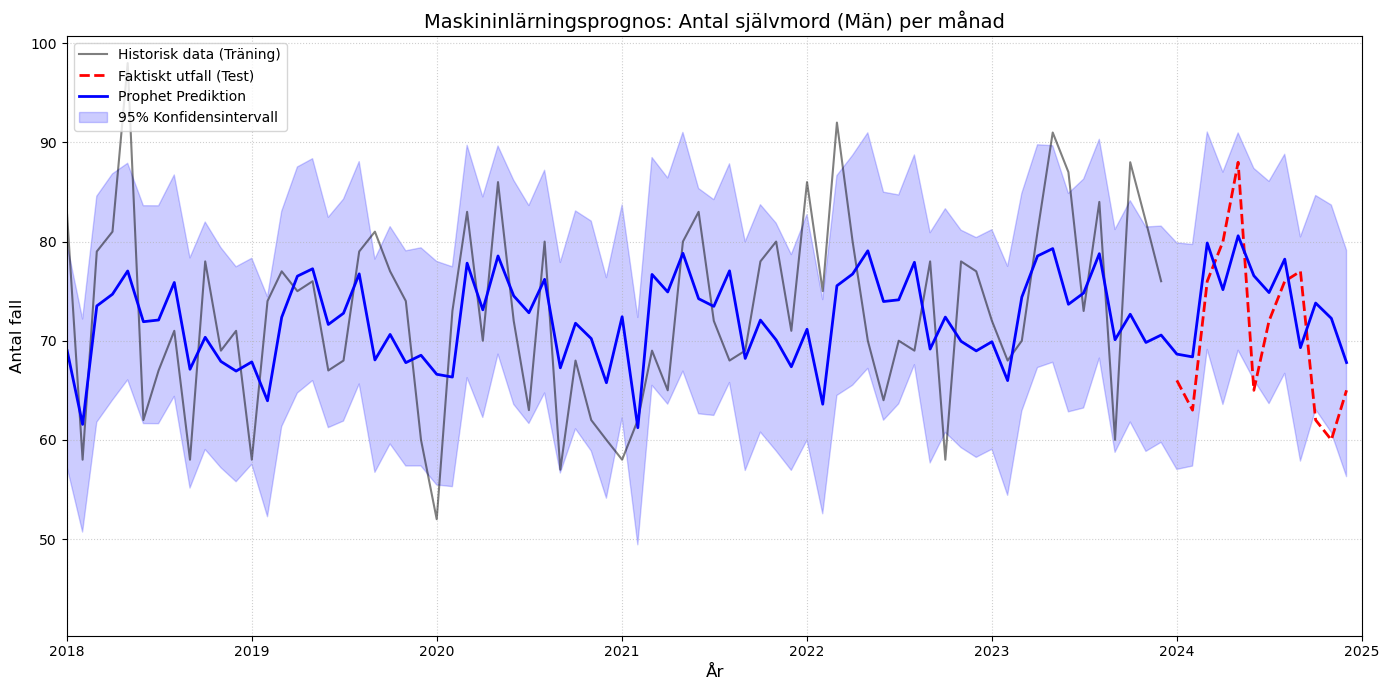


Isolerad Säsongskomponent (Viktig för beslutsfattaren!)


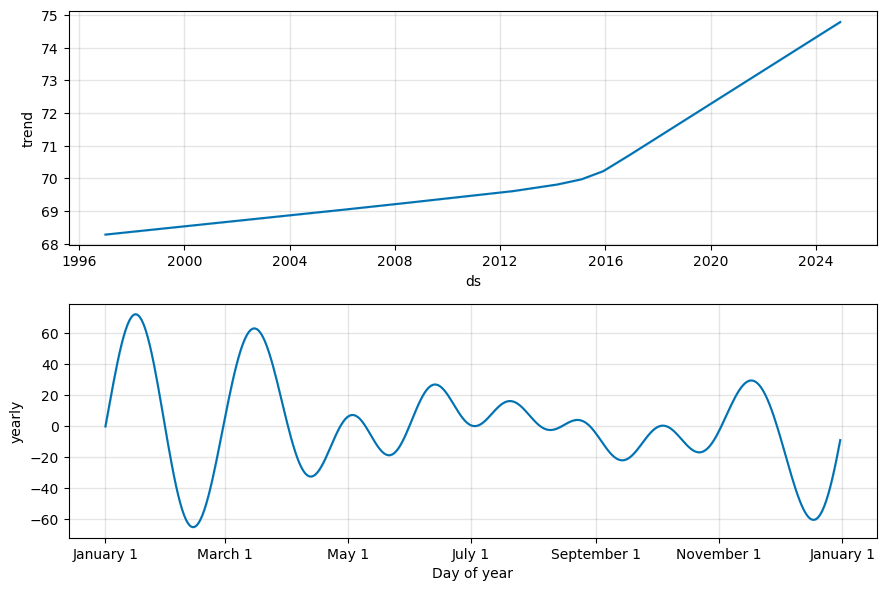

In [9]:
from prophet import Prophet
from sklearn.metrics import mean_absolute_error

print("--- STARTAR MASKININLÄRNING (PROPHET) ---")

# 1. Anpassa er befintliga df_long för Prophet
# Vi återställer indexet så 'Datum' blir en vanlig kolumn igen
df_ml = df_long.reset_index()

# Konvertera 'Period'-formatet (t.ex. 1997-01) tillbaka till en exakt dag (1997-01-01)
# Detta är avgörande eftersom Prophet måste ha ett exakt datum (ds)
df_ml['Datum'] = df_ml['Datum'].dt.to_timestamp()

# Filtrera fram Män och behåll bara de två kolumner Prophet vill ha
df_prophet_men = df_ml[df_ml['Kön'] == 'Män'][['Datum', 'Antal']].copy()

# Döp om kolumnerna till 'ds' (datestamp) och 'y' (värde) enligt Prophets hårda regler
df_prophet_men = df_prophet_men.rename(columns={'Datum': 'ds', 'Antal': 'y'})

# 2. Statistisk verifiering (Train / Test split)
# Vi låter modellen träna på all data fram till 2023
train = df_prophet_men[df_prophet_men['ds'] < '2024-01-01']
# Vi behåller 2024 som "facit" för att testa hur bra modellen är
test = df_prophet_men[(df_prophet_men['ds'] >= '2024-01-01') & (df_prophet_men['ds'] <= '2024-12-01')]

print(f"Tränar modellen på {len(train)} månader...")

# 3. Träna modellen
# Vi säger åt modellen att fokusera på årliga säsongsvariationer
model = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False)
model.fit(train)

# 4. Gör en framtidsprognos
# Vi ber modellen gissa 12 månader framåt från där träningsdatan slutade (dvs hela 2024)
future = model.make_future_dataframe(periods=12, freq='MS') # MS = Month Start
forecast = model.predict(future)

# 5. Räkna ut felmarginal (Mean Absolute Error)
predictions = forecast[forecast['ds'] >= '2024-01-01']['yhat'].values
actuals = test['y'].values

if len(predictions) == len(actuals):
    mae = mean_absolute_error(actuals, predictions)
    print(f"✅ STATISTISK VERIFIERING: Modellen gissar i snitt fel på {mae:.1f} fall per månad för 2024.")
else:
    print("Kunde inte räkna ut MAE - längden på test och prognos matchar inte.")

# 6. Visualisera resultatet (Publication Ready)
plt.figure(figsize=(14, 7), facecolor='white')

# Plotta den historiska datan vi tränade på
plt.plot(train['ds'], train['y'], color='black', alpha=0.5, label='Historisk data (Träning)')

# Plotta facit för 2024 (hur det faktiskt blev)
plt.plot(test['ds'], test['y'], color='red', linestyle='--', linewidth=2, label='Faktiskt utfall (Test)')

# Plotta modellens gissning
plt.plot(forecast['ds'], forecast['yhat'], color='blue', linewidth=2, label='Prophet Prediktion')

# Skapa det viktiga konfidensintervallet (skuggningen)
plt.fill_between(forecast['ds'], forecast['yhat_lower'], forecast['yhat_upper'], 
                 color='blue', alpha=0.2, label='95% Konfidensintervall')

plt.title('Maskininlärningsprognos: Antal självmord (Män) per månad', fontsize=14)
plt.xlabel('År', fontsize=12)
plt.ylabel('Antal fall', fontsize=12)

# Zooma in så vi ser prognosen tydligt (2018 och framåt)
plt.xlim(pd.to_datetime('2018-01-01'), pd.to_datetime('2025-01-01'))

plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='upper left', fontsize=10)
plt.tight_layout()
plt.show()

# 7. Plotta den isolerade säsongsvariationen
print("\nIsolerad Säsongskomponent (Viktig för beslutsfattaren!)")
fig_comp = model.plot_components(forecast)
plt.show()

--- STARTAR MASKININLÄRNING (SARIMA) ---
Tränar SARIMA-modellen på 324 månader... (Detta kan ta 10-20 sekunder)
✅ STATISTISK VERIFIERING: SARIMA gissar i snitt fel på 6.4 fall per månad för 2024.


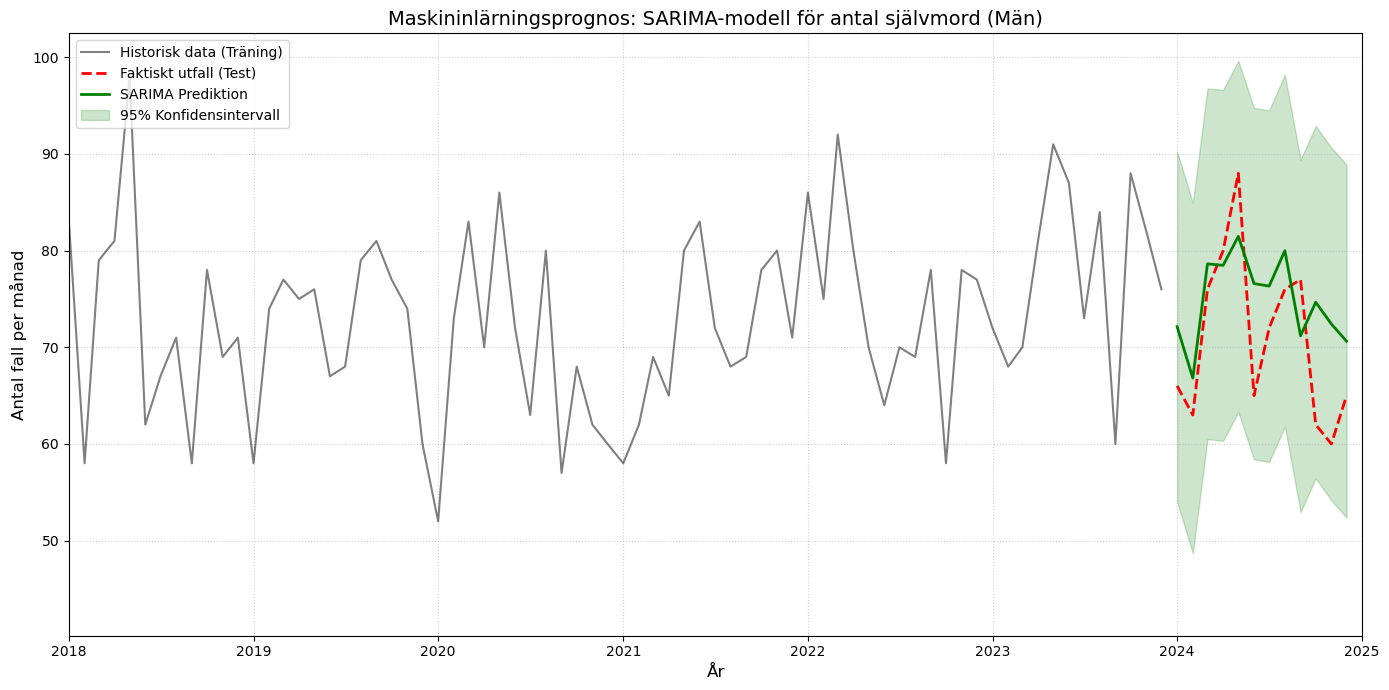


--- SLUTSATSER ---
SARIMA Felmarginal (MAE): 6.4 fall
Tips: Jämför detta MAE-värde med Prophets MAE. Den modell med lägst siffra gissar bäst på 2024!


In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error
import warnings
warnings.filterwarnings("ignore") # SARIMA gillar att printa många varningar, vi stänger av dem.

print("--- STARTAR MASKININLÄRNING (SARIMA) ---")

# 1. Förbered datan (Vi bygger vidare på er befintliga df_long)
df_sarima = df_long.reset_index()
df_sarima['Datum'] = df_sarima['Datum'].dt.to_timestamp()

# Filtrera fram Män och sätt datumet som index (SARIMA kräver detta format)
df_sarima_men = df_sarima[df_sarima['Kön'] == 'Män'][['Datum', 'Antal']].copy()
df_sarima_men.set_index('Datum', inplace=True)
# Se till att pandas vet att detta är månadsdata ('MS' = Month Start)
df_sarima_men.index = pd.DatetimeIndex(df_sarima_men.index.values, freq='MS')

# 2. Train / Test split
# Träna på data fram till slutet av 2023, testa på 2024
train_s = df_sarima_men[df_sarima_men.index < '2024-01-01']
test_s = df_sarima_men[(df_sarima_men.index >= '2024-01-01') & (df_sarima_men.index <= '2024-12-01')]

print(f"Tränar SARIMA-modellen på {len(train_s)} månader... (Detta kan ta 10-20 sekunder)")

# 3. Bygg och träna SARIMA-modellen
# Parametrar (p,d,q) och säsongsparametrar (P,D,Q,s)
# s=12 berättar för modellen att det är 12 månader på ett år.
# Dessa order-värden är standard "bra gissningar" för månadsvarierad data.
model_sarima = SARIMAX(train_s['Antal'], 
                       order=(1, 1, 1),              # Trend-parametrar
                       seasonal_order=(1, 1, 1, 12), # Säsongsparametrar (12 månader)
                       enforce_stationarity=False,
                       enforce_invertibility=False)
fitted_sarima = model_sarima.fit(disp=False)

# 4. Gör prognos för 2024 (12 steg framåt)
# Vi hämtar både prediktionen och konfidensintervallen
forecast_object = fitted_sarima.get_forecast(steps=12)
predictions_s = forecast_object.predicted_mean
conf_int_s = forecast_object.conf_int(alpha=0.05) # 95% konfidensintervall

# 5. Räkna ut felmarginal (Mean Absolute Error)
actuals_s = test_s['Antal'].values
preds_s = predictions_s.values

if len(preds_s) == len(actuals_s):
    mae_s = mean_absolute_error(actuals_s, preds_s)
    print(f"✅ STATISTISK VERIFIERING: SARIMA gissar i snitt fel på {mae_s:.1f} fall per månad för 2024.")
else:
    print("Kunde inte räkna ut MAE - kontrollera testdatan.")

# 6. Visualisera resultatet (Publication Ready)
plt.figure(figsize=(14, 7), facecolor='white')

# Historisk träningsdata
plt.plot(train_s.index, train_s['Antal'], color='black', alpha=0.5, label='Historisk data (Träning)')

# Faktiskt utfall (Facit)
plt.plot(test_s.index, test_s['Antal'], color='red', linestyle='--', linewidth=2, label='Faktiskt utfall (Test)')

# SARIMA Prognos
plt.plot(predictions_s.index, predictions_s, color='green', linewidth=2, label='SARIMA Prediktion')

# Konfidensintervall (skuggning)
plt.fill_between(conf_int_s.index, 
                 conf_int_s.iloc[:, 0], # Lägsta gränsen
                 conf_int_s.iloc[:, 1], # Högsta gränsen
                 color='green', alpha=0.2, label='95% Konfidensintervall')

plt.title('Maskininlärningsprognos: SARIMA-modell för antal självmord (Män)', fontsize=14)
plt.xlabel('År', fontsize=12)
plt.ylabel('Antal fall per månad', fontsize=12)

# Zooma in för att se skillnaden
plt.xlim(pd.to_datetime('2018-01-01'), pd.to_datetime('2025-01-01'))

plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='upper left', fontsize=10)
plt.tight_layout()
plt.show()

# 7. Jämförelse av modeller (Om ni körde Prophet innan)
print("\n--- SLUTSATSER ---")
print(f"SARIMA Felmarginal (MAE): {mae_s:.1f} fall")
print("Tips: Jämför detta MAE-värde med Prophets MAE. Den modell med lägst siffra gissar bäst på 2024!")